In [1]:
import rtoml
import os
from scipy.io import loadmat
from scipy.signal import savgol_filter
import numpy as np
from pylottone import mrdhelper
from pylottone.vis import plot_rawpt

import pylottone as pt
from pylottone import extract_raw_pt
import matplotlib.pyplot as plt

from pylottone.triggering import pt_ecg_jitter, extract_triggers
%matplotlib widget


In [2]:
cfg_ = 'configs/config_vol1321.toml'
with open(cfg_, 'r') as cf:
    cfg = rtoml.load(cf)

In [3]:

# ismrmrd_data_fullpath = '/server/home/btasdelen/MRI_DATA/pilottone/phantom0452_20251017/raw/h5/meas_MID00517_FID31601_pulseq2D_fire_spiralga_24MHz_24_05MHz_loop_loop.h5'
ismrmrd_data_fullpath = '/server/home/btasdelen/MRI_DATA/pilottone/phantom0453_20251204/raw/h5/meas_MID01458_FID35469_pulseq2D_fire_spiralga_ch1loop24MHz_ch2mpl24_05MHz_distilled.h5'

# ismrmrd_data_fullpath_cal = '/server/home/btasdelen/MRI_DATA/pilottone/phantom0452_20251017/raw/h5/meas_MID00513_FID31597_pulseq2D_fire_spiralga_24MHz_24_04MHz_calwGrad.h5'

data_dir = os.path.join('/', *(os.path.dirname(ismrmrd_data_fullpath).split('/')[:-2]))
print(f"Data dir: {data_dir}")

raw_file = ismrmrd_data_fullpath.split('/')[-1]
ismrmrd_data_fullpath, ismrmrd_noise_fullpath = mrdhelper.siemens_mrd_finder(data_dir, '', raw_file)

acq_list, wf_list, hdr = mrdhelper.read_mrd(ismrmrd_data_fullpath)
n_acq = len(acq_list)

# acq_list_cal, _, _ = mrdhelper.read_mrd(ismrmrd_data_fullpath_cal)
# get the k-space trajectory based on the metadata hash.
traj_name = hdr.userParameters.userParameterString[-1].value

# load the .mat file containing the trajectory
traj = loadmat(os.path.join(data_dir, traj_name), squeeze_me=True)

n_unique_angles = int(traj['param']['repetitions'])
pre_discard = int(traj['param']['pre_discard'])
dt = float(traj['param']['dt'])

kx = np.vstack((np.zeros((pre_discard, n_unique_angles)), traj['kx'][:,:]))
ky = np.vstack((np.zeros((pre_discard, n_unique_angles)), traj['ky'][:,:]))

data = np.array([arm.data[:,:] for arm in acq_list]).transpose(2, 0, 1)
# data_cal = np.array([arm.data[:,:] for arm in acq_list_cal]).transpose(2, 0, 1)

n_channels = data.shape[2]
sensing_coils = np.array(cfg['pilottone']['sensing_coils'], dtype=int)
mri_coils = np.arange(n_channels)
mri_coils = mri_coils[~np.isin(mri_coils, sensing_coils)]

coil_name = np.asarray([clbl.coilName for clbl in hdr.acquisitionSystemInformation.coilLabel])

print(f'Coil names: {coil_name}')
print(f"Coils to be used as sniffers: {coil_name[sensing_coils]}")

f0 = hdr.experimentalConditions.H1resonanceFrequency_Hz
df = 1/(dt*data.shape[0])

t_acq_start = acq_list[0].acquisition_time_stamp*2.5e-3 # [2.5ms] -> [s]
t_acq_end = acq_list[-1].acquisition_time_stamp*2.5e-3
time_acq = np.linspace(t_acq_start, t_acq_end, n_acq) # Interpolate for TR, as TR will not be a multiple of time resolution.
time_pt = time_acq - t_acq_start
samp_time_pt = time_acq[1] - time_acq[0]

# t_acq_cal_start = acq_list_cal[0].acquisition_time_stamp*2.5e-3 # [2.5ms] -> [s]
# t_acq_cal_end = acq_list_cal[-1].acquisition_time_stamp*2.5e-3
# time_acq_cal = np.linspace(t_acq_cal_start, t_acq_cal_end, len(acq_list_cal)) # Interpolate for TR, as TR will not be a multiple of time resolution.
# time_pt_cal = time_acq_cal - t_acq_cal_start

ksp_measured = data #[:,:,mri_coils]
# ksp_cal = data_cal #[:,:,mri_coils]
# ksp_sniffer  = data[:,:,sensing_coils]

## Process ECG waveform
wf_dict = mrdhelper.waveforms_asarray2(wf_list)
if 'pulseox' in wf_dict:
    time_pulseox = wf_dict['pulseox'][0] - acq_list[0].acquisition_time_stamp*2.5e-3
    pulseox_waveform = wf_dict['pulseox'][1]
    pulseox_trigs = wf_dict['pulseox'][2]
# if ecg is not None:
#     ecg_waveform = ecg['ecg_waveform']
#     ecg_waveform = pt.check_waveform_polarity(ecg_waveform, 0.5)*ecg_waveform
#     time_ecg = ecg['time_ecg'] - acq_list[0].acquisition_time_stamp*2.5e-3
#     ecg_trigs = ecg['ecg_trigs']
# else:
#     print('No ECG waveform found, skipping the validation part.')
# plt.figure()
# plt.plot(time_ecg, ecg_waveform)
# plt.plot(time_ecg[ecg_trigs==1], ecg_waveform[ecg_trigs==1], '*')

Data dir: /server/home/btasdelen/MRI_DATA/pilottone/phantom0453_20251204
Reading /server/home/btasdelen/MRI_DATA/pilottone/phantom0453_20251204/raw/h5/meas_MID01458_FID35469_pulseq2D_fire_spiralga_ch1loop24MHz_ch2mpl24_05MHz_distilled.h5...
Reading acquisitions...
There are 8640 acquisitions in the dataset.
There are 3005 waveforms in the dataset.
Finished reading /server/home/btasdelen/MRI_DATA/pilottone/phantom0453_20251204/raw/h5/meas_MID01458_FID35469_pulseq2D_fire_spiralga_ch1loop24MHz_ch2mpl24_05MHz_distilled.h5 in 3.66 seconds.
Coil names: ['Body_6:1:B12' 'Body_6:1:B13' 'Body_6:1:B21' 'Body_6:1:B11'
 'Body_6:1:B23' 'Body_6:1:B22' 'Spine_18:1:S1P' 'Spine_18:1:S1S'
 'Spine_18:1:S2S' 'Spine_18:1:S2P' 'Spine_18:1:S1T' 'Spine_18:1:S2T'
 'Spine_18:1:S3P' 'Spine_18:1:S3S' 'Spine_18:1:S3T' 'Spine_18:1:S4T'
 'Spine_18:1:S4S' 'Spine_18:1:S4P']
Coils to be used as sniffers: ['Spine_18:1:S4T' 'Spine_18:1:S4S' 'Spine_18:1:S4P']


 ## PT correction

In [5]:
f_pt = [24.0e6, 24.05e6]


In [6]:
pt_raw_list = []
pt_cplx_list = []
for f_pt_ in f_pt:
    f_diff = f0 - f_pt_
    # ksp_measured_wht = apply_prewhitening(np.transpose(ksp_measured, (2,0,1)), dmtx).transpose((1,2,0))
    # ksp_cal_wht = apply_prewhitening(np.transpose(ksp_cal, (2,0,1)), dmtx).transpose((1,2,0))


    # ksp_measured = ksp_measured@Vrvr

    # pt_raw_cal, _ = extract_raw_pt(ksp_cal, kx, ky, n_unique_angles, acq_list[0], f_diff, df, dt, method='sine', freq_correction=True, return_complex=False)
    pt_cplx_, _ = extract_raw_pt(ksp_measured, kx, ky, n_unique_angles, acq_list[0], f_diff, df, dt, method='wPCA', freq_correction=True, return_complex=True)
    pt_cplx_list.append(pt_cplx_)
    pt_raw = np.abs(pt_cplx_) - np.mean(np.abs(pt_cplx_), axis=0, keepdims=True)
    pt_raw_list.append(pt_raw)

# Plot coils and raw PT

In [ ]:
coil_name

/server/home/btasdelen/workspace/PyPilotTone/.venv/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


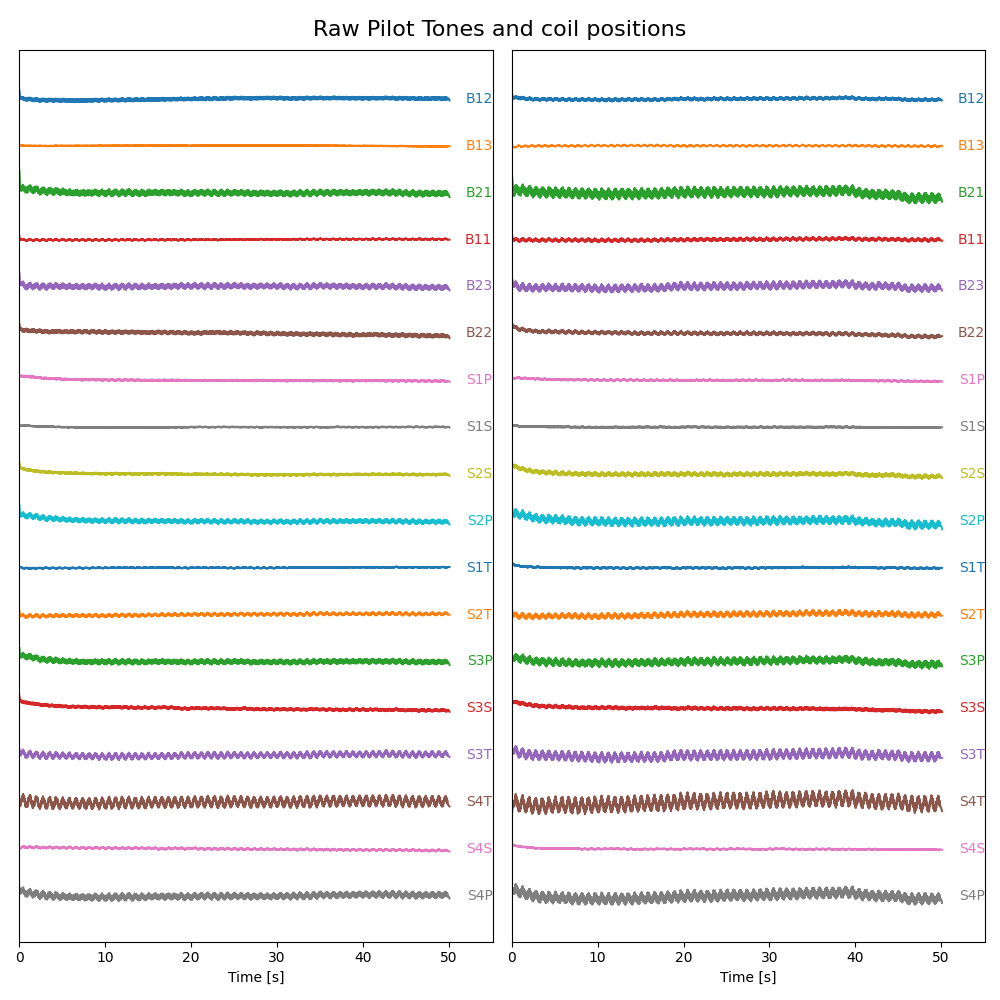

In [8]:
from pylottone.vis import plot_rawpt_compare
coil_name_abbr = np.array([name[-3:] for name in coil_name])
pt_raw_filt0 = savgol_filter(pt_raw_list[0], 81, 3, axis=0)
pt_raw_filt1 = savgol_filter(pt_raw_list[1], 81, 3, axis=0)

# f, axs = plot_rawpt(pt_raw_filt1, coil_name_abbr, time_pt, sort=True, drawcoils=True)
f, axs = plot_rawpt_compare(pt_raw_filt0, pt_raw_filt1, coil_name_abbr, time_pt, sort=False)


In [9]:
from typing import Literal

def modulation_percentage(signal: np.ndarray, signal_mean: np.ndarray, mode: Literal['extent', 'std', 'percentile'] = 'extent') -> float:
    """Calculate the modulation percentage of a signal.

    Args:
        signal (np.ndarray): Filtered input signal.
        signal_mean (np.ndarray): Mean of the raw pilot tone signal.
    Returns:
        modulation_pct (float): Modulation percentage.
    """
    if mode == 'extent':
        modulation = np.max(signal, axis=0) - np.min(signal, axis=0)
    elif mode == 'std':
        modulation = np.std(signal, axis=0)
    elif mode == 'percentile':
        modulation = np.percentile(signal, 95, axis=0) - np.percentile(signal, 5, axis=0)
    modulation_pct = (modulation / signal_mean) * 100
    return modulation_pct

In [ ]:
pt_cardiac.shape

In [ ]:
from pylottone.signal import designbp_tukeyfilt_freq, apply_filter_freq
from pylottone.sobi import sobi

f_samp = 1/samp_time_pt
n_pt_samp = pt_raw.shape[0]
# filt_bp_resp = designbp_tukeyfilt_freq(cfg['pilottone']['respiratory']['freq_start'], cfg['pilottone']['respiratory']['freq_stop'], f_samp, n_pt_samp)
# pt_respiratory_freqs = apply_filter_freq(pt_raw_filt, filt_bp_resp, 'symmetric')


filt_bp_cardiac = designbp_tukeyfilt_freq(cfg['pilottone']['cardiac']['freq_start'], cfg['pilottone']['cardiac']['freq_stop'], f_samp, n_pt_samp)
pt_cardiac_freqs = apply_filter_freq(pt_raw_filt, filt_bp_cardiac, 'symmetric')
# plot_rawpt(pt_respiratory_freqs, coil_name, time_pt, sort=False, drawcoils=False)
_, axs = plot_rawpt(pt_cardiac_freqs, coil_name, time_pt, sort=False, drawcoils=False)
plt.suptitle('Cardiac PT.')

delays, max_corrs,_ = pt.signal.xcorr_channels(pt_cardiac_freqs, 8)

print(f"Delays: {delays}, max corrs: {max_corrs}")
accept_chs = np.abs(max_corrs) > 0.8
# accept_chs = np.abs(delays) < 40

print(f"Accepted channels: {coil_name[accept_chs]} with delays: {delays[accept_chs]}")

pt_cardiac, Ucard, Vcard = sobi(pt_cardiac_freqs[:, accept_chs].T, num_lags=600)
_,axs = plot_rawpt(pt_cardiac.T, np.array([f"Src {i}" for i in range(pt_cardiac.shape[0])]), time_pt, sort=False, drawcoils=False)
plt.suptitle('SOBI sources.')
picked_chs, env_stds = pt.pick_cardiac_source(pt_cardiac.T, f_samp)
card_ch = picked_chs[np.argmin(env_stds)]
print(f"Picked channels: {picked_chs}, with stds: {env_stds}")

pt_cardiac = (Ucard[:,card_ch][:,None])@(pt_cardiac[card_ch,:][None,:])
# pt_cardiac = ((pt_cardiac.T[:,0])[:,None]@Ucard[0,:][None,:]).T

_, axs = plot_rawpt(pt_cardiac.T, coil_name, time_pt, sort=False, drawcoils=False)
plt.suptitle('Back projected cardiac PT')
# axs[0].vlines([88.817, 89.13],  ymin=-1.5e-3, ymax=1.5e-3, color='k', lw=1, linestyle='--')
# axs[0].vlines([88.85, 89.166],  ymin=-1.5e-3, ymax=1.5e-3, color='r', lw=1, linestyle='--')

plt.figure()
plt.plot(time_pt, pt_cardiac_freqs)
# card_chs = [0, 1, 2, 4, 5, 8]
# plt.figure()
# plt.subplot(2,1,1)
# plt.plot(time_pt, pt_respiratory_freqs/np.percentile(pt_respiratory_freqs, 99, axis=0), label='Respiratory Pilot Tone')
# plt.subplot(2,1,2)
# plt.plot(time_pt, pt_cardiac_freqs[:, card_chs]/np.percentile(np.abs(pt_cardiac_freqs[:, card_chs]), 99, axis=0), label='Cardiac Pilot Tone')
# plt.legend(coil_name[card_chs])

print(f"{modulation_percentage(pt_cardiac.T, np.mean(np.abs(pt_raw_cplx[:, accept_chs]), axis=0), mode='std')}%")


In [ ]:
from pylottone.vis import plot_rawpt_compare
from pylottone.signal import designbp_tukeyfilt_freq, apply_filter_freq
from pylottone.sobi import sobi
coil_name_abbr = np.array([name[-3:] for name in coil_name])
f_samp = 1/samp_time_pt
n_pt_samp = pt_raw_list[0].shape[0]
pt_cardiac_list = []
for ii, f_pt_ in enumerate(f_pt):
    pt_raw = pt_raw_list[ii]
    pt_raw_filt = savgol_filter(pt_raw, 81, 3, axis=0)

    filt_bp_cardiac = designbp_tukeyfilt_freq(cfg['pilottone']['cardiac']['freq_start'], cfg['pilottone']['cardiac']['freq_stop'], f_samp, n_pt_samp)
    pt_cardiac_freqs = apply_filter_freq(pt_raw_filt, filt_bp_cardiac, 'symmetric')
    # plot_rawpt(pt_respiratory_freqs, coil_name, time_pt, sort=False, drawcoils=False)
    # _, axs = plot_rawpt(pt_cardiac_freqs, coil_name, time_pt, sort=False, drawcoils=False)
    # plt.suptitle('Cardiac PT.')

    delays, max_corrs,_ = pt.signal.xcorr_channels(pt_cardiac_freqs, 8)

    # print(f"Delays: {delays}, max corrs: {max_corrs}")
    accept_chs = np.abs(max_corrs) > 0.6
    # accept_chs = np.abs(delays) < 40

    print(f"Accepted channels: {coil_name[accept_chs]} with delays: {delays[accept_chs]}")

    pt_cardiac, Ucard, Vcard = sobi(pt_cardiac_freqs[:, accept_chs].T, num_lags=600)
    # _,axs = plot_rawpt(pt_cardiac.T, np.array([f"Src {i}" for i in range(pt_cardiac.shape[0])]), time_pt, sort=False, drawcoils=False)
    # plt.suptitle('SOBI sources.')
    picked_chs, env_stds = pt.pick_cardiac_source(pt_cardiac.T, f_samp)
    card_ch = picked_chs[np.argmin(env_stds)]
    # print(f"Picked channels: {picked_chs}, with stds: {env_stds}")

    pt_cardiac = (Ucard[:,card_ch][:,None])@(pt_cardiac[card_ch,:][None,:])
    # pt_cardiac = ((pt_cardiac.T[:,0])[:,None]@Ucard[0,:][None,:]).T

    # _, axs = plot_rawpt(pt_cardiac.T, coil_name, time_pt, sort=False, drawcoils=False)
    # plt.suptitle('Back projected cardiac PT')
    pt_cardiac_list.append(pt_cardiac)
    m_pctgs = modulation_percentage(pt_cardiac.T, np.mean(np.abs(pt_cplx_list[ii][:, accept_chs]), axis=0), mode='extent')
    print(f"{m_pctgs}, mean mp: {np.mean(m_pctgs)}%, max mp: {np.max(m_pctgs)}%")

plot_rawpt_compare(pt_cardiac_list[0][:,:].T, pt_cardiac_list[1].T, coil_name_abbr[accept_chs], time_pt, sort=False)

In [ ]:
plt.figure()
plt.plot(time_ecg, ecg_waveform)
plt.plot(time_ecg[ecg_trigs==1], ecg_waveform[ecg_trigs==1], '*', label='ECG Triggers')

ecg_trig_diffs = np.diff(time_ecg[ecg_trigs==1])
plt.figure()
plt.plot(60/ecg_trig_diffs, marker='o')
plt.ylabel('Heart Rate [bpm]')
plt.xlabel('Time [s]')





In [ ]:
plot_rawpt(savgol_filter(np.abs(pt_raw) - np.mean(np.abs(pt_raw), axis=0, keepdims=True), 81, 3, axis=0), coil_name, time_pt, sort=True, drawcoils=False)

In [ ]:
coil_name[5]

 ## QA and ECG PT Jitter

In [ ]:
import importlib
import pylottone
import pylottone.pt

importlib.reload(pylottone)
importlib.reload(pylottone.pt)

f_samp = 1/samp_time_pt # [Hz]
print(f"Using {cfg['pilottone']['cardiac']['initial_channel']} as the initial cardiac coil.")
pt_extract_params = {'golay_filter_len': cfg['pilottone']['golay_filter_len'],
                    'respiratory': {
                            'freq_start': cfg['pilottone']['respiratory']['freq_start'],
                            'freq_stop': cfg['pilottone']['respiratory']['freq_stop'],
                            'corr_threshold': cfg['pilottone']['respiratory']['corr_threshold'],
                            'corr_init_ch': cfg['pilottone']['respiratory']['initial_channel'],
                            'separation_method': cfg['pilottone']['respiratory']['separation_method'], # 'sobi', 'pca'
                    },
                    'cardiac': {
                                'freq_start': cfg['pilottone']['cardiac']['freq_start'],
                                'freq_stop': cfg['pilottone']['cardiac']['freq_stop'],
                                'corr_threshold': 0.8, #cfg['pilottone']['cardiac']['corr_threshold'],
                                'corr_init_ch': 0, #np.nonzero(coil_name == cfg['pilottone']['cardiac']['initial_channel'])[0][0],                           
                                'separation_method': 'sobi', #cfg['pilottone']['cardiac']['separation_method'], # 'sobi', 'pca'
                                'num_lags': 600, # SOBI number of lags
                    },
                    'debug': {
                        'selected_coils': cfg['pilottone']['debug']['selected_coils'],
                        'coil_legend': coil_name[mri_coils],
                        'show_plots': cfg['pilottone']['debug']['show_plots'],
                        'no_normalize': cfg['pilottone']['debug']['no_normalize'],
                    }
                }

sg_filter_len = 81

cal_select = (time_pt > 40) & (time_pt < 60)
pt_respiratory, pt_cardiac = pt.extract_pilottone_navs(pt_raw, f_samp, pt_extract_params)
# Vresp, accept_list_resp, pt_respiratory_cal, Vcard, accept_list_cardiac, pt_cardiac_cal = pt.calibrate_pt(pt_raw[cal_select,:], f_samp, pt_extract_params)
# Vresp, accept_list_resp, pt_respiratory_cal, Vcard, accept_list_cardiac, pt_cardiac_cal = pt.calibrate_pt(pt_raw_cal, f_samp, pt_extract_params)
# pt_respiratory, pt_cardiac = pt.apply_pt_calib(pt_raw, Vresp, accept_list_resp, Vcard.T, accept_list_cardiac, f_samp, pt_extract_params)

time_pt2 = time_pt

pt_cardiac = cfg['pilottone']['cardiac']['sign']*pt_cardiac
pt_cardiac[:20] = pt_cardiac[20]
pt_cardiac[-20:] = pt_cardiac[-20]
pt_cardiac -= np.percentile(pt_cardiac, 10)
pt_cardiac /= np.percentile(pt_cardiac, 95)

pt_cardiac_filtered = savgol_filter(pt_cardiac, sg_filter_len, 3, axis=0)
pt_cardiac_derivative = np.hstack((0, np.diff(pt_cardiac_filtered)/(time_pt[1] - time_pt[0])))
pt_cardiac_derivative[:20] = pt_cardiac_derivative[20]
pt_cardiac_derivative[-20:] = pt_cardiac_derivative[-20]
pt_cardiac_derivative -= np.percentile(pt_cardiac_derivative, 10)
pt_cardiac_derivative /= np.percentile(pt_cardiac_derivative, 98)

pt_cardiac_trigs = extract_triggers(time_pt2, pt_cardiac, skip_time=1, prominence=0.4, max_hr=160)
pt_derivative_trigs = extract_triggers(time_pt2, pt_cardiac_derivative, skip_time=1, prominence=0.5, max_hr=160)

if ecg is not None:
    _,_ = pt_ecg_jitter(time_pt2, pt_cardiac, pt_cardiac_derivative,
                        time_ecg, ecg_waveform, 
                        pt_cardiac_trigs=pt_cardiac_trigs, pt_derivative_trigs=pt_derivative_trigs, ecg_trigs=ecg_trigs, 
                        skip_time=1, show_outputs=cfg['pilottone']['show_outputs'])
    plt.figure()
    plt.plot(time_pt2, pt_respiratory, label='Respiratory')
    plt.xlabel('Time [s]')
    plt.show()
elif ecg is None and cfg['pilottone']['show_outputs']:
    pt_trig_diffs = np.diff(time_pt[pt_derivative_trigs==1])

    fig, axs = plt.subplots(3,1, figsize=(10, 6), sharex=True)
    axs[0].plot(time_pt2, pt_cardiac, label='Cardiac')
    axs[0].plot(time_pt2, pt_cardiac_derivative, label='Cardiac Derivative')
    axs[0].plot(time_pt2[pt_cardiac_trigs==1], pt_cardiac[pt_cardiac_trigs==1], '*', label='Cardiac Triggers')
    axs[0].plot(time_pt2[pt_derivative_trigs==1], pt_cardiac_derivative[pt_derivative_trigs==1], '*', label='Cardiac Derivative Triggers')
    axs[0].set_title('Cardiac Triggers')
    axs[0].legend()
    axs[1].plot(time_pt[pt_derivative_trigs==1][1:], 60/pt_trig_diffs, marker='o')
    axs[1].set_ylabel('Heart Rate [bpm]')
    axs[2].plot(time_pt2, pt_respiratory, label='Respiratory')
    axs[2].set_title('Respiratory')
    axs[2].set_xlabel('Time [s]')
    axs[2].legend()

    plt.show()



In [ ]:
2/samp_time_pt

In [ ]:
samp_time_pt*100

In [ ]:
plt.figure()
plt.plot(pt_respiratory_cal, label='Respiratory Calibration')
plt.plot(pt_cardiac_cal, label='Cardiac Calibration')
plt.show()
pt_raw_cal = pt_raw[cal_select,:]
plot_rawpt(pt_raw_cal, coil_name[mri_coils], np.arange(pt_raw_cal.shape[0])*(time_pt[1]), sort=True, drawcoils=True)


In [ ]:
import copy
pt_extract_params2 = copy.deepcopy(pt_extract_params)
pt_extract_params2['cardiac']['freq_stop'] = 6
Vresp, accept_list_resp, pt_respiratory_cal, Vcard, accept_list_cardiac, pt_cardiac_cal = pt.calibrate_pt(pt_raw_cal, f_samp, pt_extract_params)
print(Vcard)
Vresp, accept_list_resp, pt_respiratory_cal, Vcard, accept_list_cardiac, pt_cardiac_cal = pt.calibrate_pt(pt_raw_cal, f_samp, pt_extract_params2)
print(Vcard)


## Try rovir

In [ ]:
# TODO: Make interactive selection of regions for signal and interference
10, 15, 23, 28, 36, 41, 49, 54, 62, 67
interference_mask = (time_pt > 10) & (time_pt < 15) | \
                    (time_pt > 23) & (time_pt < 28) | \
                    (time_pt > 36) & (time_pt < 41) | \
                    (time_pt > 49) & (time_pt < 54) | \
                    (time_pt > 62) & (time_pt < 67)
signal_mask = ~interference_mask
pt_raw_filt = savgol_filter(pt_raw, 81, 3, axis=0)
Vrvr, pt_rvr, SIR, SNR = calc_rovir(pt_raw_filt, signal_mask, interference_mask)

In [ ]:
np.linalg.vector_norm(Vrvr, axis=0, keepdims=True, ord=2)  # Normalize eigenvectors

In [ ]:
f, axs = plot_rawpt(pt_raw_filt, coil_name[mri_coils], time_pt, sort=False)


In [ ]:
from scipy.linalg import qr
from scipy.linalg import inv
Vrvr2,_ = qr(Vrvr)
f, axs = plot_rawpt(pt_raw_filt@Vrvr2, coil_name[mri_coils], time_pt, sort=False)
cumSNR = np.cumsum(SNR)
cumSNR /= cumSNR[-1]  # Normalize SNR for plotting
# Make separate y axis for SNR and SIR
# plt.figure()
# plt.plot(cumSNR, label='SNR', color='red')
# ax2 = plt.twinx(plt.gca())
# ax2.plot(SIR, label='SIR')
# ax2.set_xticks(np.arange(len(SIR)))
# plt.xlabel('Coil number')
# plt.legend()
# plt.show()

In [ ]:
plt.figure()
plt.subplot(1, 3, 1)
plt.plot(time_pt, pt_raw2.real)
plt.subplot(1, 3, 2)
plt.plot(time_pt, pt_raw2.imag)
plt.subplot(1, 3, 3)
plt.plot(time_pt, np.abs(pt_raw2+np.abs(pt_raw2).max()))
plt.figure()
plt.plot(np.angle(pt_raw2))
plt.show()

In [ ]:
from scipy.linalg import pinv
import copy
pt_extract_params2 = copy.deepcopy(pt_extract_params)
# pt_extract_params2['cardiac']['initial_channel'] = 4

n_sel_ch = 18

pt_raw2 = np.abs(((pt_raw @ Vrvr[:, :n_sel_ch]))) #@ pinv(Vrvr[:, :n_sel_ch])
# pt_raw2 = np.abs(pt_raw2+np.abs(pt_raw2).max())
# pt_raw2 = pt_raw2.imag
f, axs = plot_rawpt(savgol_filter(pt_raw2 - np.mean(pt_raw2, axis=0, keepdims=True), cfg['pilottone']['golay_filter_len'], 3, axis=0), np.array([f"V{i}" for i in range(n_ch)]), time_pt, sort=False, drawcoils=False)
f, axs = plot_rawpt(savgol_filter(np.abs(pt_raw) - np.mean(np.abs(pt_raw), axis=0, keepdims=True), cfg['pilottone']['golay_filter_len'], 3, axis=0), coil_name[mri_coils], time_pt, sort=False, drawcoils=False)

# pt_raw_cal2 = (pt_raw_cal@ Vrvr[:, :n_sel_ch]@ pinv(Vrvr[:, :n_sel_ch]))
# pt_raw_cal2 = np.abs(pt_raw_cal2+np.abs(pt_raw_cal2).max())
pt_raw_cal2 = pt_raw_cal
Vresp, accept_list_resp, pt_respiratory_cal, Vcard, accept_list_cardiac, pt_cardiac_cal = pt.calibrate_pt(pt_raw_cal2, f_samp, pt_extract_params2)
pt_respiratory, pt_cardiac = pt.apply_pt_calib(pt_raw2, Vresp, accept_list_resp, Vcard.T, accept_list_cardiac, f_samp, pt_extract_params2)


In [ ]:
Vrvr

In [ ]:
pt_respiratory, pt_cardiac = pt.apply_pt_calib(pt_raw, Vrvr, np.arange(0, n_ch), Vrvr, np.arange(0, n_ch), f_samp, pt_extract_params2)


In [ ]:
# pt_respiratory, pt_cardiac = pt.extract_pilottone_navs(pt_raw, f_samp, pt_extract_params)
n_sel_ch = 18
pt_raw2 = (pt_raw @ Vrvr2[:, :n_sel_ch]) @ Vrvr2[:, :n_sel_ch].conj().T

Vresp, accept_list_resp, pt_respiratory_cal, Vcard, accept_list_cardiac, pt_cardiac_cal = pt.calibrate_pt((pt_raw_cal@ Vrvr2[:, :n_sel_ch]) @ Vrvr2[:, :n_sel_ch].conj().T, f_samp, pt_extract_params)
pt_respiratory, pt_cardiac = pt.apply_pt_calib(pt_raw2, Vresp, accept_list_resp, Vcard.T, accept_list_cardiac, f_samp, pt_extract_params)


In [ ]:


pt_cardiac = cfg['pilottone']['cardiac']['sign']*pt_cardiac
pt_cardiac[:20] = pt_cardiac[20]
pt_cardiac[-20:] = pt_cardiac[-20]
pt_cardiac -= np.percentile(pt_cardiac, 10)
pt_cardiac /= np.percentile(pt_cardiac, 95)

pt_cardiac_filtered = savgol_filter(pt_cardiac, sg_filter_len, 3, axis=0)
pt_cardiac_derivative = np.hstack((0, np.diff(pt_cardiac_filtered)/(time_pt[1] - time_pt[0])))
pt_cardiac_derivative[:20] = pt_cardiac_derivative[20]
pt_cardiac_derivative[-20:] = pt_cardiac_derivative[-20]
pt_cardiac_derivative -= np.percentile(pt_cardiac_derivative, 10)
pt_cardiac_derivative /= np.percentile(pt_cardiac_derivative, 98)

pt_cardiac_trigs = extract_triggers(time_pt, pt_cardiac, skip_time=1, prominence=0.4, max_hr=160)
pt_derivative_trigs = extract_triggers(time_pt, pt_cardiac_derivative, skip_time=1, prominence=0.5, max_hr=160)

if ecg is not None:
    _,_ = pt_ecg_jitter(time_pt, pt_cardiac, pt_cardiac_derivative,
                        time_ecg, ecg_waveform, 
                        pt_cardiac_trigs=pt_cardiac_trigs, pt_derivative_trigs=pt_derivative_trigs, ecg_trigs=ecg_trigs, 
                        skip_time=1, show_outputs=cfg['pilottone']['show_outputs'])
    f, axs = plt.subplots(2,1)

    axs[0].plot(time_pt, pt_respiratory, label='Respiratory')
    plt.legend()
    axs[1].plot(time_pt, pt_cardiac, label='Cardiac', color='green')
    axs[1].set_xlabel('Time [s]')
    plt.legend()
    plt.show()
elif ecg is None and cfg['pilottone']['show_outputs']:
    fig, axs = plt.subplots(2,1, figsize=(10, 6), sharex=True)
    axs[0].plot(time_pt, pt_cardiac, label='Cardiac')
    axs[0].plot(time_pt, pt_cardiac_derivative, label='Cardiac Derivative')
    axs[0].plot(time_pt[pt_cardiac_trigs==1], pt_cardiac[pt_cardiac_trigs==1], '*', label='Cardiac Triggers')
    axs[0].plot(time_pt[pt_derivative_trigs==1], pt_cardiac_derivative[pt_derivative_trigs==1], '*', label='Cardiac Derivative Triggers')
    axs[0].set_title('Cardiac Triggers')
    axs[0].set_xlabel('Time [s]')
    axs[0].legend()
    axs[1].plot(time_pt, pt_respiratory, label='Respiratory')
    axs[1].set_title('Respiratory')
    axs[1].set_xlabel('Time [s]')
    axs[1].legend()
    plt.show()


